#### Build a model to find whether the person will be defaulter for loan or not when income & balance of the person is provided

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("C:/Users/ASUS/Desktop/FBS/Data science/Dataset/Default.csv")
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [4]:
data.shape

(10000, 4)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [6]:
data.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462905
50%,823.636973,34552.644800
75%,1166.308387,43807.729275
max,2654.322576,73554.233500


{'whiskers': [<matplotlib.lines.Line2D at 0x1eedf7d9a90>,
 'caps': [<matplotlib.lines.Line2D at 0x1eedf86de50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eedf7db4d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1eedf86e0d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eedf86e210>],
 'means': []}

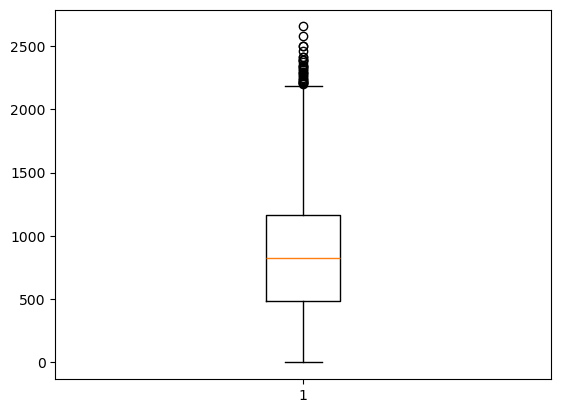

In [7]:
plt.boxplot(data['balance'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1eedf916e90>,
 'caps': [<matplotlib.lines.Line2D at 0x1eedf917110>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eedf916d50>],
 'medians': [<matplotlib.lines.Line2D at 0x1eedf917390>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eedf9174d0>],
 'means': []}

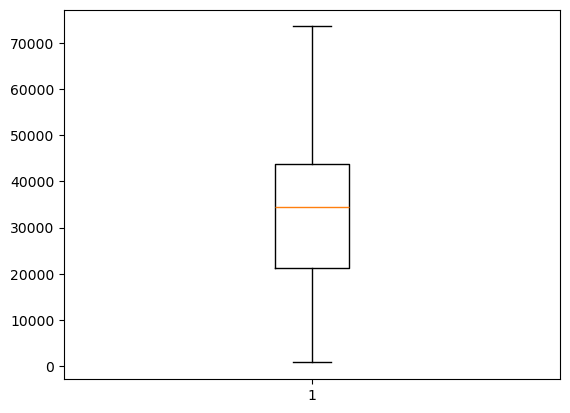

In [8]:
plt.boxplot(data['income'])

In [9]:
mean_bal = data['balance'].mean()
mean_bal

np.float64(835.3748856149443)

In [10]:
std_bal = data['balance'].std()
std_bal

483.71498521033266

In [11]:
data[data['balance']>(mean_bal + 3 * std_bal)].shape[0]

20

In [12]:
data.drop(data[data['balance']>(mean_bal + 3 * std_bal)].index,inplace = True)

In [13]:
data.shape

(9980, 4)

In [14]:
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [15]:
data.drop(['student'],axis = 1,inplace = True)

In [16]:
data.head()

,default,balance,income
0,No,729.526495,44361.62507
1,No,817.180407,12106.13470
2,No,1073.549164,31767.13895
3,No,529.250605,35704.49394
4,No,785.655883,38463.49588


In [17]:
X = data.drop(['default'],axis = 1)
y = data['default']

In [18]:
data.describe()

,balance,income
count,9980.000000,9980.000000
mean,832.247137,33530.953295
std,479.101692,13331.877798
min,0.000000,771.967729
25%,481.127011,21357.458397
50%,821.496224,34562.497710
75%,1164.542737,43810.685280
max,2269.946966,73554.233500


In [19]:
y.value_counts()

default
No     9663
Yes     317
Name: count, dtype: int64

In [20]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()

In [21]:
X_sm,y_sm = sm.fit_resample(X,y)

In [22]:
y_sm.value_counts()

default
No     9663
Yes    9663
Name: count, dtype: int64

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [24]:
X_scaler = scaler.fit_transform(X_sm)

In [25]:
from sklearn.model_selection import train_test_split

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X_scaler,y_sm,test_size = 0.2,random_state = 10)

In [28]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 15)

In [29]:
model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=15)

In [30]:
test_predict = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_test,test_predict)

0.9115364718054837

In [33]:
from sklearn.metrics import confusion_matrix
res = confusion_matrix(y_test,test_predict)
res

array([[1654,  262],
       [  80, 1870]])

In [34]:
pd.DataFrame(res,columns = ['pred -ve','pred +ve'],index =['actual -ve','actual +ve'])

,pred -ve,pred +ve
actual -ve,1654,262
actual +ve,80,1870


##### Precision and Recall

In [35]:
from sklearn.metrics import precision_score,recall_score

In [37]:
precision_score(y_test,test_predict,pos_label = 'Yes')

0.8771106941838649

In [38]:
1859 / (1859 + 276)

0.8707259953161592

In [39]:
recall_score(y_test,test_predict,pos_label = 'Yes')

0.958974358974359

In [40]:
1859 / (1859 + 91)

0.9533333333333334